# The Body as a Reference point

**Agathe Salmon**

*31th of May 2026*

The human body is the first space a speaker inhabits. Lakoff & Johnson (1980), in *Metaphors We Live By*, argued that abstract concepts such as time and space are routinely understood through embodied experience. Heine (1997) showed that body-part terms are a major cross-linguistic source for grammatical and spatial vocabulary, and more recent typological work (Brown 1976, Majid et al. 2018) confirms that the body is one of the most productive metaphorical domains worldwide. 

This project investigates whether the body's primary spatial experience leaves traces in the lexicon of the world's languages, using colexifications.

By mapping these colexifications across language families and geographic areas, I intended to identify which body parts function as the most productive conceptual hubs, and whether certain language families show stronger or different patterns of embodied metaphor.

## 1. Library imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations
import folium
from folium.plugins import MarkerCluster

## 2. Data import

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeykosh/intro-to-ling-2026/refs/heads/main/s8/lexibank_clipped.csv',
                           low_memory=False, index_col=0)
df

,Language_ID,Form,Latitude,Longitude,Glottocode,Concepticon_Gloss,Family
0,aaleykusunda-KusundaK,ɐ̃ː.ʤi,28.000000,82.260000,kusu1250,ABOVE,NaN
1,abrahammonpa-MonpaKalaktang,thuŋga,27.104162,92.113017,kala1376,ABOVE,Sino-Tibetan
2,abrahammonpa-MonpaDirang,thuŋga,27.349590,92.279140,tsha1245,ABOVE,Sino-Tibetan
3,abrahammonpa-MonpaChangprong,jur,27.578928,91.876393,dakp1242,ABOVE,Sino-Tibetan
4,abrahammonpa-SartangDarbuB,khuŋlo,27.329171,92.358727,sart1249,ABOVE,Sino-Tibetan
...,...,...,...,...,...,...,...
709633,yangyi-Pholaypg,lɑ̠²³pʰɔ³³,23.456381,102.286862,phol1237,GROOM,Sino-Tibetan
709634,yangyi-Phuzaypz,sa³³ɛ¹³ɕa⁵⁵,23.253698,103.332621,phuz1235,GROOM,Sino-Tibetan
709635,yangyi-SouthernMujiymc,mi²¹ɬji⁵⁵a²¹pa²¹,22.895906,103.222074,sout2722,GROOM,Sino-Tibetan
709636,yangyi-HlephoPhowayhl,za²¹sɿ³³ma³³,23.333902,103.721759,hlep1236,GROOM,Sino-Tibetan


## 3. Word list creation

In [8]:
BODY = {
    'back':         ['BACK', 'SPINE'],
    'belly':        ['BELLY', 'STOMACH', 'WOMB'],
    'chest':        ['CHEST', 'BREAST'],
    'face':         ['FACE', 'FOREHEAD', 'CHEEK', 'CHIN'],
    'head':         ['HEAD', 'SKULL'],
    'foot':         ['FOOT', 'HEEL', 'TOE'],
    'leg':          ['LEG', 'KNEE', 'THIGH', 'SHIN'],
    'heart':        ['HEART'],
    'liver':        ['LIVER'],
    'intestines':   ['INTESTINES'],
    'lungs':        ['LUNG'],
    'hand':         ['HAND', 'FIST', 'WRIST', 'FINGER'],
    'arm':          ['ARM', 'ELBOW', 'SHOULDER'],
    'eye':          ['EYE', 'EYELID', 'EYEBROW'],
    'ear':          ['EAR'],
    'mouth':        ['MOUTH', 'LIP', 'TONGUE', 'TOOTH'],
    'nose':         ['NOSE', 'NOSTRIL'],
    'tail':         ['TAIL'],
    'bone':         ['BONE', 'MARROW'],
    'skin':         ['SKIN', 'HIDE'],
    'blood':        ['BLOOD'],
}

TEMPORAL = {
    'future':       ['TOMORROW', 'SOON'],
    'past':         ['YESTERDAY', 'BEFORE', 'LONG AGO'],
    'present':      ['NOW', 'TODAY'],
    'time_gen':     ['TIME', 'WHEN', 'WHILE', 'THEN', 'UNTIL'],
    'duration':     ['YEAR', 'MONTH', 'SEASON', 'HOUR', 'NIGHT',
                     'MORNING', 'EVENING', 'NOON', 'WEEK'],
    'sequence':     ['FIRST', 'NEXT', 'AGAIN', 'ALREADY'],
    'calendar':     ['MOON', 'SUN'],
    'begin_end':    ['BEGIN', 'START', 'FINISH'],
}

SPATIAL = {
    'front':        ['FORWARD'],
    'back':         ['BEHIND', 'BACKWARD'],
    'up':           ['ABOVE', 'UP', 'HIGH'],
    'down':         ['DOWN'],
    'side':         ['SIDE', 'BESIDE', 'NEXT TO'],
    'far':          ['FAR'],
    'near':         ['NEAR'],
    'here':         ['HERE'],
    'there':        ['THERE', 'THAT'],
    'inside':       ['INSIDE'],
    'outside':      ['OUTSIDE'],
    'center':       ['MIDDLE', 'CENTER', 'BETWEEN'],
    'edge':         ['EDGE', 'BORDER'],
    'from':         ['FROM'],
}

In [9]:
ALL_BODY     = {c for grp in BODY.values()     for c in grp}
ALL_TEMPORAL = {c for grp in TEMPORAL.values() for c in grp}
ALL_SPATIAL = {c for grp in SPATIAL.values() for c in grp}

body_concept_to_group    = {c: g for g, cs in BODY.items()     for c in cs}
temporal_concept_to_group = {c: g for g, cs in TEMPORAL.items() for c in cs}
spatial_concept_to_group = {c: g for g, cs in SPATIAL.items() for c in cs}

## 2. Colexifications detections

### 2.1 Function

In [10]:
def find_colexifications(df, concepts_a, concepts_b, 
                         label_a='concept_a', label_b='concept_b',
                         group_map_a=None, group_map_b=None):
  
    mask = df['Concepticon_Gloss'].isin(concepts_a | concepts_b)
    sub  = df[mask].copy()
    rows = []

    for (lang, form), grp in sub.groupby(['Language_ID', 'Form']):
        glosses = set(grp['Concepticon_Gloss'].dropna())
        in_a = glosses & set(concepts_a)
        in_b = glosses & set(concepts_b)

        for ca in in_a:
            for cb in in_b:
                if ca != cb:
                    meta = grp.iloc[0]
                    rows.append({
                        label_a:        ca,
                        label_b:        cb,
                        'Language_ID':  lang,
                        'Form':         form,
                        'Family':       meta['Family'],
                        'Latitude':     meta['Latitude'],
                        'Longitude':    meta['Longitude'],
                        'Glottocode':   meta['Glottocode'],
                    })

    if not rows:
        return pd.DataFrame()

    result = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=[label_a, label_b, 'Language_ID'])
        .reset_index(drop=True)
    )

   
    result[f'{label_a}_group'] = result[label_a].map(group_map_a)
    result[f'{label_b}_group'] = result[label_b].map(group_map_b)

    return result

### 2.2 General Colexifications Datasets 

In [11]:
colex_body_time = find_colexifications(df, ALL_BODY, ALL_TEMPORAL, 'body_words', 'time_words', body_concept_to_group, temporal_concept_to_group)
colex_body_time.head(5)

,body_words,time_words,Language_ID,Form,Family,Latitude,Longitude,Glottocode,body_words_group,time_words_group
0,EYE,SUN,aaleykusunda-KusundaK,iːŋ,NaN,28.000000,82.260000,kusu1250,eye,calendar
1,MOUTH,MOON,abvdoceanic-DaakakaWestAmbrymVanuatu,bung,Austronesian,-16.269600,168.013000,daka1243,mouth,calendar
2,SKIN,MOON,abvdoceanic-Vano,mele,Austronesian,-11.610700,166.798400,vano1237,skin,calendar
3,BLOOD,YEAR,allenbai-Eryuan,sua⁴⁴,Sino-Tibetan,26.538056,99.910000,eryu1239,blood,duration
4,BLOOD,YEAR,allenbai-Heqing,sʰua⁴⁴,Sino-Tibetan,26.099137,99.941616,heqi1238,blood,duration


In [12]:
colex_body_space = find_colexifications(df, ALL_BODY, ALL_SPATIAL, 'body_words', 'space_words', body_concept_to_group, spatial_concept_to_group)
colex_body_time.head(5)

,body_words,time_words,Language_ID,Form,Family,Latitude,Longitude,Glottocode,body_words_group,time_words_group
0,EYE,SUN,aaleykusunda-KusundaK,iːŋ,NaN,28.000000,82.260000,kusu1250,eye,calendar
1,MOUTH,MOON,abvdoceanic-DaakakaWestAmbrymVanuatu,bung,Austronesian,-16.269600,168.013000,daka1243,mouth,calendar
2,SKIN,MOON,abvdoceanic-Vano,mele,Austronesian,-11.610700,166.798400,vano1237,skin,calendar
3,BLOOD,YEAR,allenbai-Eryuan,sua⁴⁴,Sino-Tibetan,26.538056,99.910000,eryu1239,blood,duration
4,BLOOD,YEAR,allenbai-Heqing,sʰua⁴⁴,Sino-Tibetan,26.099137,99.941616,heqi1238,blood,duration


## 3. Analysis

### 3.1 Which body parts are the most colexified with time words

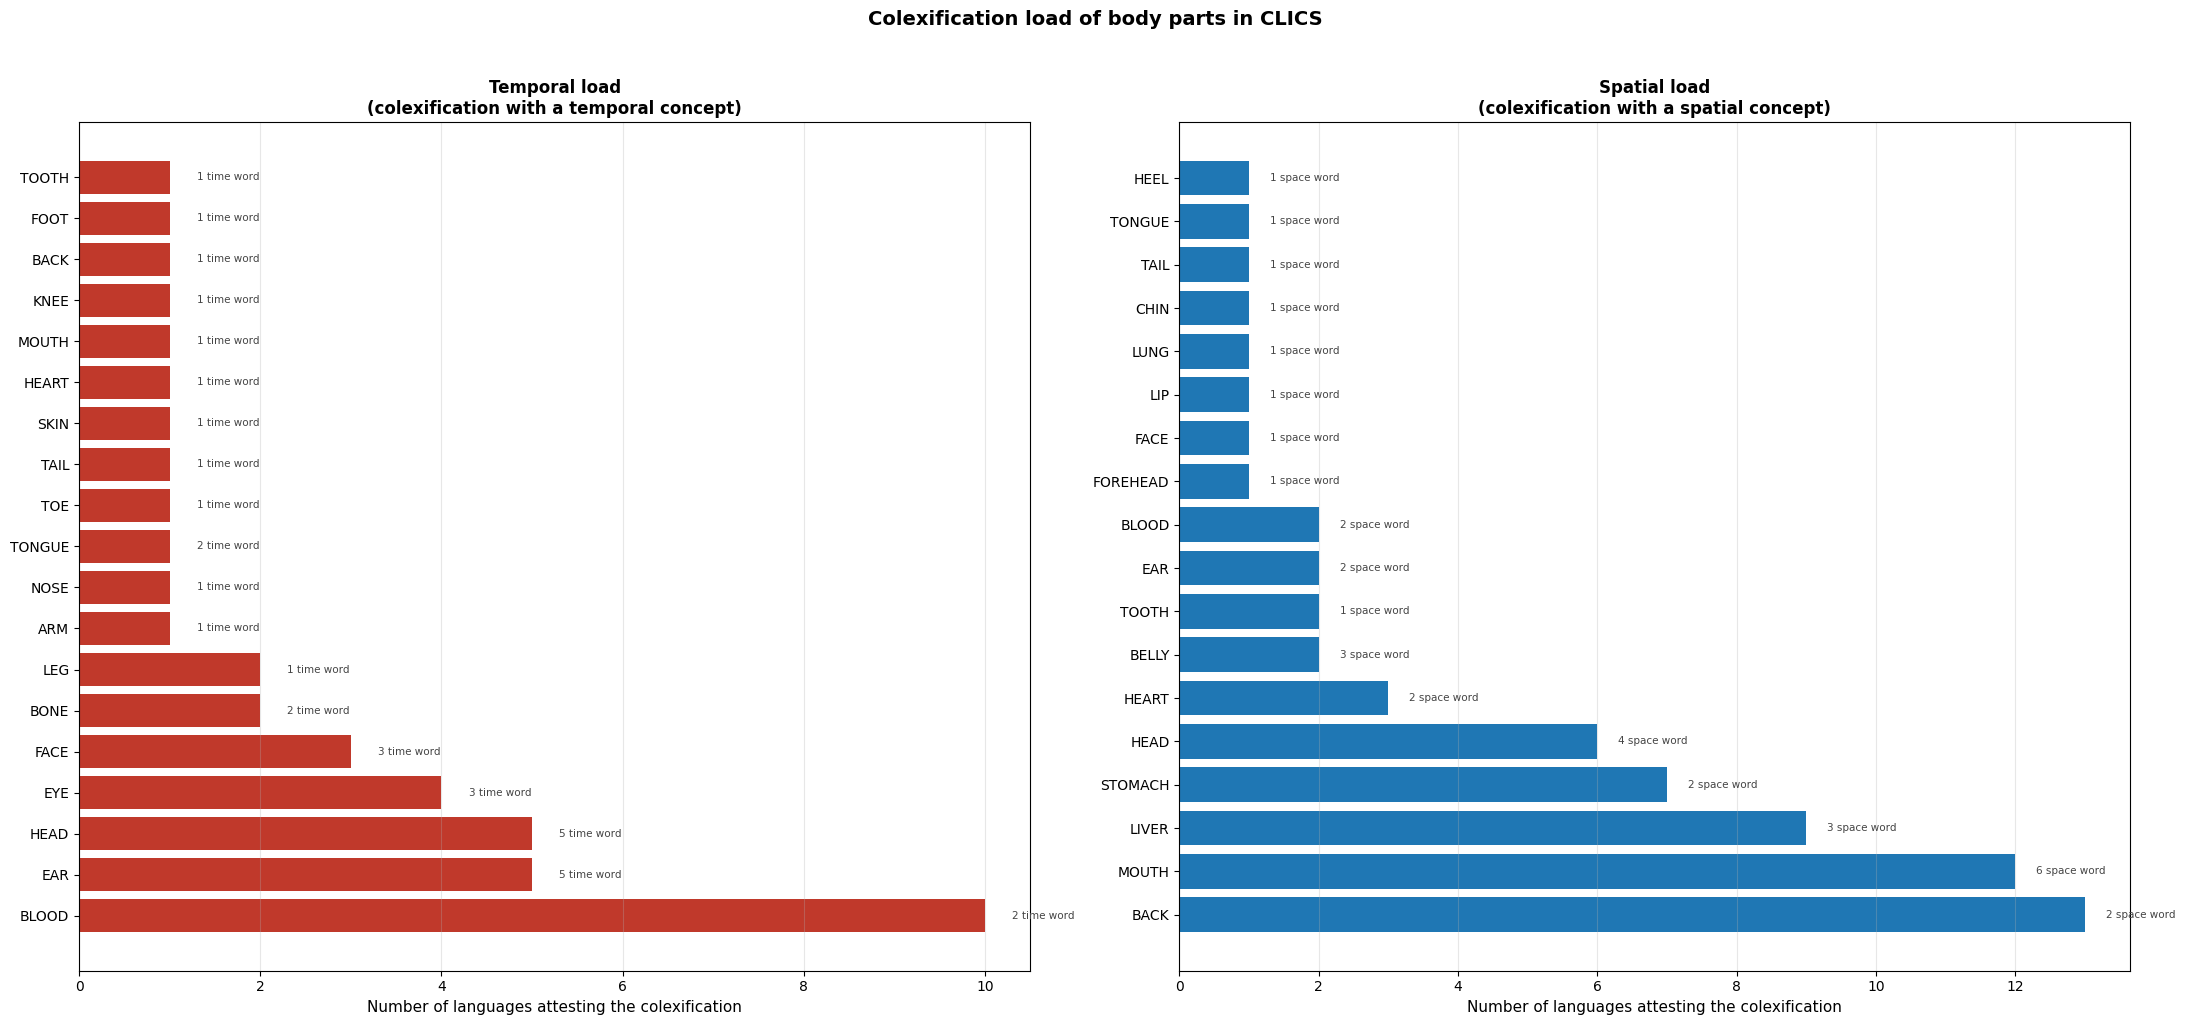

In [15]:
body_charge_time = (
    colex_body_time
    .groupby('body_words')
    .agg(
        n_languages_total = ('Language_ID', 'nunique'),
        n_concepts        = ('time_words',  'nunique'),
        n_families        = ('Family',      'nunique'),
        time_concepts     = ('time_words',  lambda x: ', '.join(sorted(x.unique())[:6])),
    )
    .sort_values('n_languages_total', ascending=False)
    .reset_index()
)

body_charge_space = (
    colex_body_space
    .groupby('body_words')
    .agg(
        n_languages_total = ('Language_ID', 'nunique'),
        n_concepts        = ('space_words', 'nunique'),
        n_families        = ('Family',      'nunique'),
        space_concepts    = ('space_words', lambda x: ', '.join(sorted(x.unique())[:6])),
    )
    .sort_values('n_languages_total', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
datasets = [
    (body_charge_time,  'time word',  'Temporal load\n(colexification with a temporal concept)',  axes[0], '#c0392b'),
    (body_charge_space, 'space word', 'Spatial load\n(colexification with a spatial concept)',   axes[1], None),
]

for df, label, title, ax, color in datasets:
    bars = ax.barh(df['body_words'], df['n_languages_total'], color=color)
    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['n_concepts']} {label}",
            va='center', fontsize=7.5, color='#444'
        )
    ax.set_xlabel('Number of languages attesting the colexification', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Colexification load of body parts in CLICS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()    

Spatial colexifications recruit a wider and more diverse set of body parts than temporal ones: nearly every body region maps onto at least one spatial concept, whereas only a handful (HEAD, EYE, BLOOD, MOUTH) carry a meaningful temporal load. This is a first indication that the body-to-space mapping is more lexically productive than the body-to-time mapping.

### 3.2 Visualising colexifications

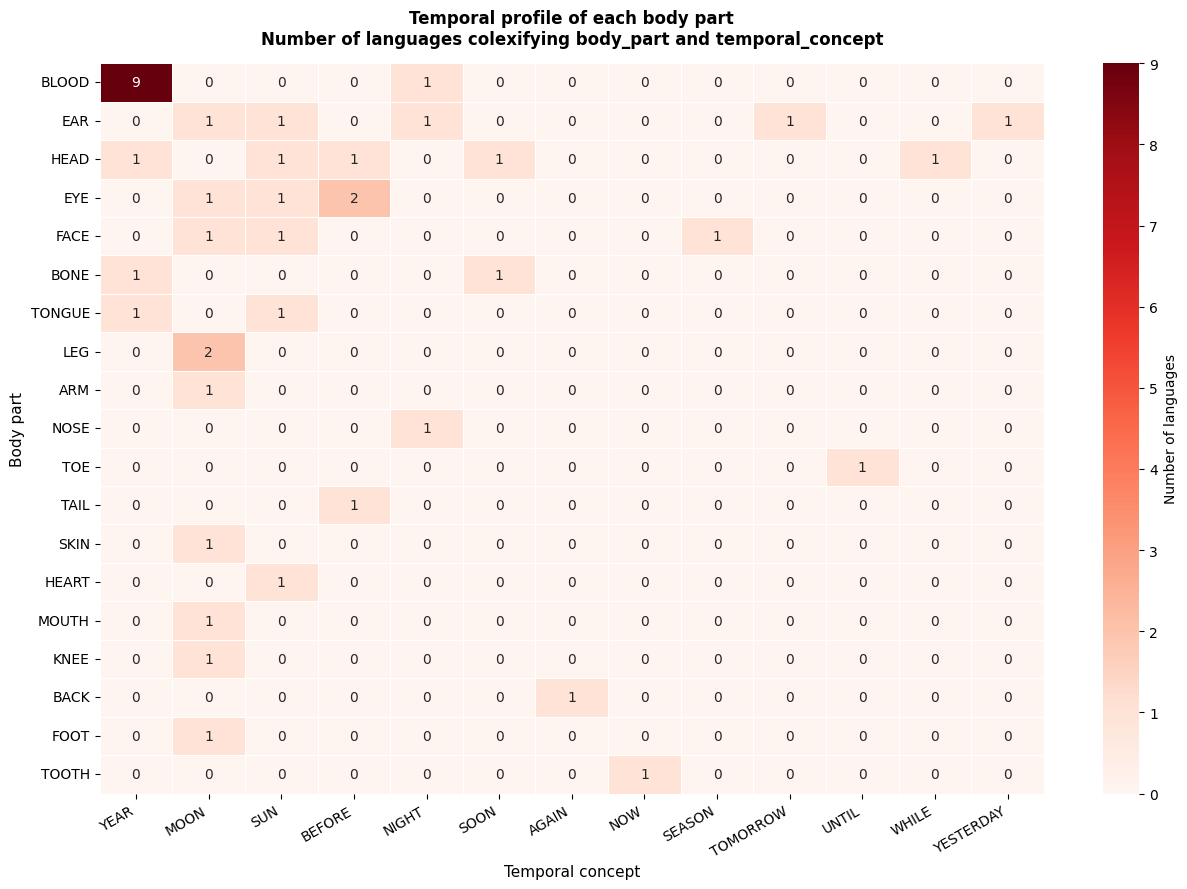

In [16]:
heatmap_data = (
    colex_body_time
    .groupby(['body_words', 'time_words'])['Language_ID']
    .nunique()
    .unstack(fill_value=0)
)

row_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
col_order = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    heatmap_data, ax=ax,
    annot=True, fmt='d',
    cmap='Reds',
    linewidths=0.4,
    cbar_kws={'label': 'Number of languages'},
)
ax.set_title('Temporal profile of each body part\n'
             'Number of languages colexifying body_part and temporal_concept',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Temporal concept', fontsize=11)
ax.set_ylabel('Body part', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Body-to-time colexifications are sparse and scattered — most cells in the heatmap are empty or contain a single language. The clearest signal is BLOOD × YEAR (driven by Sino-Tibetan languages where the same form denotes both), and the calendar concepts SUN and MOON act as the main temporal anchors, often mapped onto visible body parts (EYE, MOUTH).

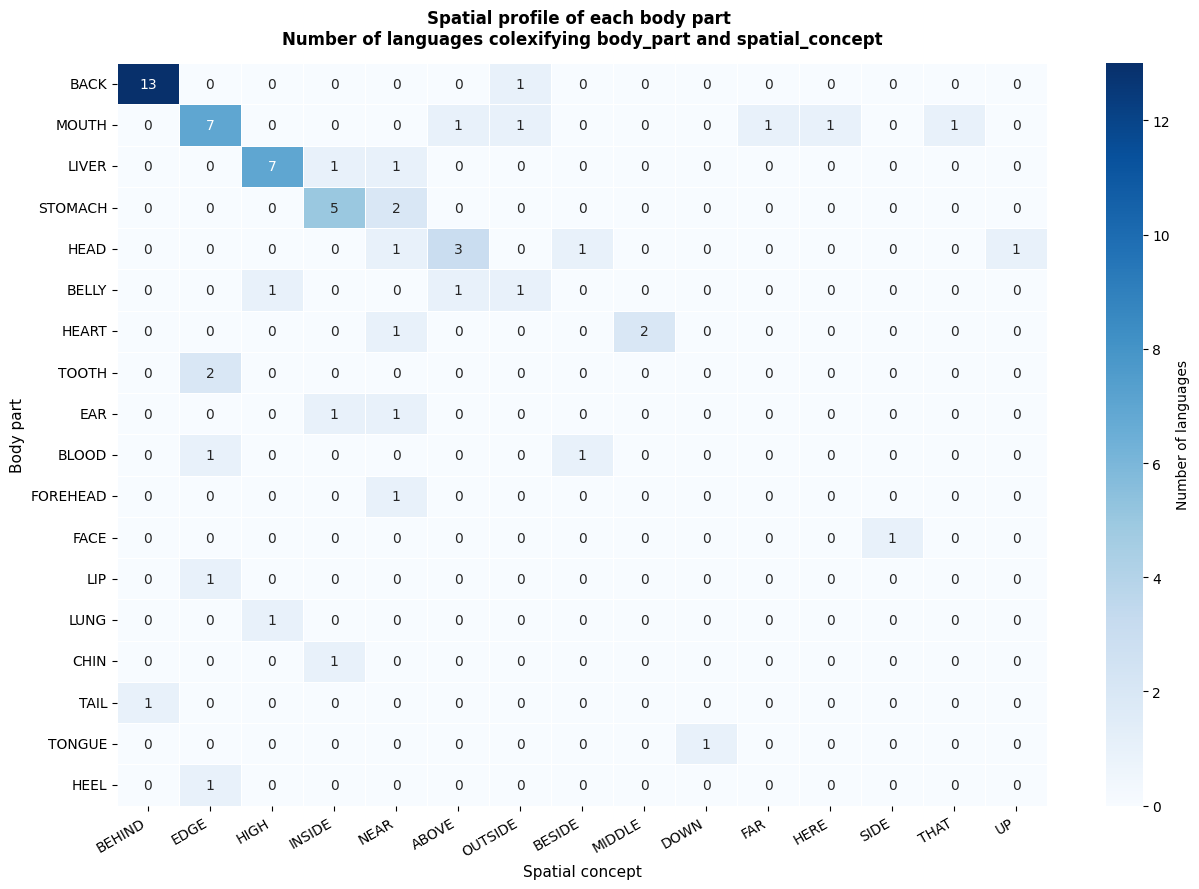

In [17]:
heatmap_data = (
    colex_body_space
    .groupby(['body_words', 'space_words'])['Language_ID']
    .nunique()
    .unstack(fill_value=0)
)

row_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
col_order = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    heatmap_data, ax=ax,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.4,
    cbar_kws={'label': 'Number of languages'},
)
ax.set_title('Spatial profile of each body part \n'
             'Number of languages colexifying body_part and spatial_concept',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Spatial concept', fontsize=11)
ax.set_ylabel('Body part', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Body-to-space colexifications are denser and more structurally coherent. BACK × BEHIND, STOMACH × INSIDE, HEAD × ABOVE, and MOUTH × EDGE recur across many unrelated languages, suggesting that these mappings reflect the geometry of the body itself rather than chance lexicalisation patterns.

### 3.3 Families distribution

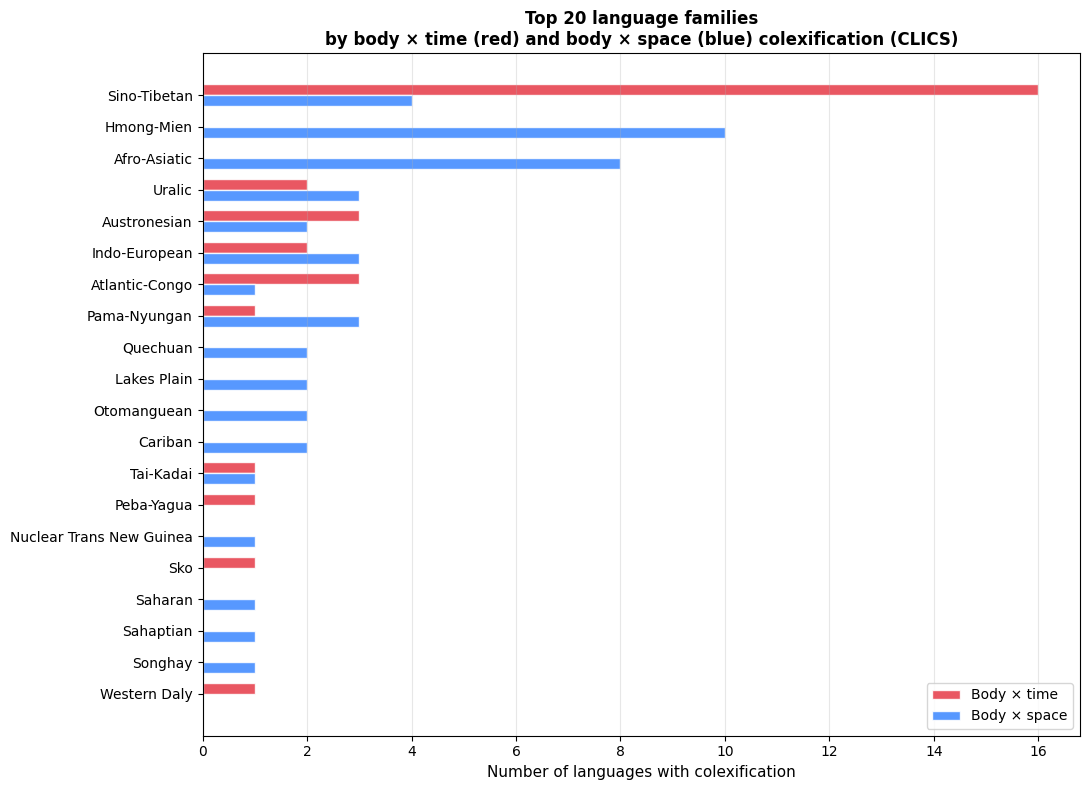

In [18]:
top_n = 20

fam_counts_time = (
    colex_body_time
    .groupby('Family')['Language_ID'].nunique()
    .reset_index()
    .rename(columns={'Language_ID': 'n_time'})
)

fam_counts_space = (
    colex_body_space
    .groupby('Family')['Language_ID'].nunique()
    .reset_index()
    .rename(columns={'Language_ID': 'n_space'})
)

merged = (
    fam_counts_time
    .merge(fam_counts_space, on='Family', how='outer')
    .fillna(0)
    .assign(total=lambda d: d['n_time'] + d['n_space'])
    .sort_values('total', ascending=False)
    .head(top_n)
    .sort_values('total', ascending=True)  
)

fig, ax = plt.subplots(figsize=(11, 8))

y      = np.arange(len(merged))
height = 0.35

ax.barh(y + height/2, merged['n_time'],  height, color='#E63946', alpha=0.85, edgecolor='white', label='Body × time')
ax.barh(y - height/2, merged['n_space'], height, color='#3A86FF', alpha=0.85, edgecolor='white', label='Body × space')

ax.set_yticks(y)
ax.set_yticklabels(merged['Family'])
ax.set_xlabel('Number of languages with colexification', fontsize=11)
ax.set_title(f'Top {top_n} language families\nby body × time (red) and body × space (blue) colexification (CLICS)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

The same families dominate both colexification types, but with very uneven weights. Sino-Tibetan is heavily over-represented for body × time (mostly driven by the BLOOD × YEAR pair), while Austronesian, Atlantic-Congo, and Indo-European show the broadest body × space repertoires. Part of this skew likely reflects CLICS sampling rather than a genuine typological asymmetry.

### 3.4 Mapping colexifications

In [19]:
def aggregate(df, concept_col):
    return (
        df.dropna(subset=['Latitude', 'Longitude'])
          .groupby(['Language_ID', 'Latitude', 'Longitude'])
          .agg(
              family     = ('Family',      lambda x: x.iloc[0] if not x.isna().all() else 'Unknown'),
              body_parts = ('body_words',  lambda x: ', '.join(sorted(x.unique()))),
              concepts   = (concept_col,   lambda x: ', '.join(sorted(x.unique()))),
          )
          .reset_index()
    )

agg_time  = aggregate(colex_body_time,  'time_words')
agg_space = aggregate(colex_body_space, 'space_words')

m = folium.Map(location=[10, 20], zoom_start=2, tiles='CartoDB positron')

space_layer = folium.FeatureGroup(name=f'Body × space (n={agg_space.shape[0]})', show=True)
for _, row in agg_space.iterrows():
    popup_html = (
        f"<b>{row['Language_ID']}</b><br>"
        f"Family: {row['family']}<br>"
        f"Body part: {row['body_parts']}<br>"
        f"Space concept: {row['concepts']}"
    )
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4, color='white', weight=0.5,
        fill=True, fill_color='#3A86FF', fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"{row['Language_ID']} (space)",
    ).add_to(space_layer)
space_layer.add_to(m)

time_layer = folium.FeatureGroup(name=f'Body × time (n={agg_time.shape[0]})', show=True)
for _, row in agg_time.iterrows():
    popup_html = (
        f"<b>{row['Language_ID']}</b><br>"
        f"Family: {row['family']}<br>"
        f"Body part: {row['body_parts']}<br>"
        f"Time concept: {row['concepts']}"
    )
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4, color='white', weight=0.5,
        fill=True, fill_color='#E63946', fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"{row['Language_ID']} (time)",
    ).add_to(time_layer)
time_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m  

## 4. Conclusion

Three patterns emerge. First, the body is clearly a more productive metaphorical source for space than for time: body × space colexifications are more frequent, involve more body parts, and recur across more unrelated language families. This is consistent with Heine's (1997) finding that body parts are a primary source for spatial adpositions, and with the broader claim of conceptual metaphor theory that abstract domains are grounded in more concrete ones (Lakoff & Johnson 1980).

Second, the most cross-linguistically robust mappings are those that follow the geometry of the body itself: (back and behind ,stomach and inside, head and above, mouth and edge). These are the cases where the colexification is attested in many genealogically distinct families, suggesting that the mapping reflects shared embodied experience rather than inheritance or contact.

Third, body × time colexifications are much rarer and tend to cluster within specific families (notably Sino-Tibetan for BLOOD × YEAR). This pattern suggests that the body-to-time route, when it exists, is typically family-specific and culturally mediated rather than a near-universal — unlike the body-to-space route.
These results come with caveats. CLICS does not sample all families equally, the colexification method only catches words that are formally identical (not all metaphorical extensions), and the concept lists used here are practical rather than exhaustive. A more refined analysis would need to control for family size and to compare formal identity with the polysemy patterns reported in descriptive grammars. 